# 04b. BERT Sentiment Analysis — Full Corpus

Runs BERT sentiment scoring on all 10,116 English-language reviews.
This is the GPU-accelerated version — requires an NVIDIA GPU with sufficient VRAM.
Tested on RTX 4070 Laptop GPU.

**Input:** `../Data/Processed/ushmm_tripadvisor_eng_vader.csv`  
**Output:** `../Data/Processed/ushmm_full_with_bert.csv`

**Note:** This replaces the `ushmm_full_with_bert.csv` produced by `04_bert.ipynb`,
which only populated bert_score for the 1,242 stratified sample rows.
After running this notebook, all 10,116 rows will have a bert_score.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import random
from transformers import pipeline

In [4]:
random.seed(7)
np.random.seed(7)
torch.manual_seed(7)

device = 0 if torch.cuda.is_available() else -1
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("No GPU — this will take a long time on CPU")

GPU available: True
Device: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM: 8.6 GB


In [5]:
df = pd.read_csv("../Data/Processed/ushmm_tripadvisor_eng_vader.csv")
print(f"Loaded {len(df)} reviews")
df.head()

Loaded 10116 reviews


,likes,rating,review_text,group_type,reviewer_location,emo_vader,eval_vader,emo_eval_bucket
0,0,5,We spent four hours and could have spent eight...,COUPLES,"Bradley, Illinois",0.4201,0.4201,Emo+ / Eval+
1,1,5,We are Germans visiting this museum. Most of t...,FAMILY,"Heidelberg, Germany",0.7096,0.7096,Emo+ / Eval+
2,0,5,This museum is incredible and incredibly impor...,FAMILY,"Otsego, Minnesota",0.3875,0.3875,Emo+ / Eval+
3,0,5,I visited the Holocaust Museum in August 2024....,SOLO,"New York City, New York",-0.6712,0.0000,Mixed / Neutral
4,0,4,I learned so much. The place has a very sad vi...,FRIENDS,"Lewiston, New York",-0.5256,0.0754,Mixed / Neutral


## 1. Run BERT on All Reviews

Estimated time on RTX 4070: ~2–3 minutes for 10,116 reviews.

In [6]:
clf = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

texts = df["review_text"].astype(str).tolist()
preds = clf(texts, batch_size=64, truncation=True, max_length=256)
print(f"Done. {len(preds)} reviews scored.")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 777.34it/s]


Done. 10116 reviews scored.


In [7]:
def signed_score(row):
    return row["score"] if row["label"] == "POSITIVE" else -row["score"]

df["bert_score"] = [signed_score(p) for p in preds]

print("BERT score distribution (full corpus):")
print(df["bert_score"].describe().round(3))

BERT score distribution (full corpus):
count    10116.000
mean         0.669
std          0.715
min         -1.000
25%          0.979
50%          0.998
75%          1.000
max          1.000
Name: bert_score, dtype: float64


## 2. Results

In [8]:
print("Mean BERT score by star rating:")
print(df.groupby("rating")["bert_score"].mean().round(3))

print("\nMean BERT score by group type:")
print(df.groupby("group_type")["bert_score"].mean().round(3))

print("\nCorrelation (BERT vs rating):",
      df[["bert_score", "rating"]].corr().iloc[0, 1].round(3))

Mean BERT score by star rating:
rating
1   -0.789
2   -0.803
3   -0.366
4    0.541
5    0.779
Name: bert_score, dtype: float64

Mean BERT score by group type:
group_type
BUSINESS    0.797
COUPLES     0.654
FAMILY      0.660
FRIENDS     0.726
NONE        0.645
SOLO        0.677
Name: bert_score, dtype: float64

Correlation (BERT vs rating): 0.414


In [9]:
print("Full correlation matrix:")
print(df[["bert_score", "emo_vader", "eval_vader", "rating"]].corr().round(3))

Full correlation matrix:
            bert_score  emo_vader  eval_vader  rating
bert_score       1.000      0.208       0.261   0.414
emo_vader        0.208      1.000       0.896   0.080
eval_vader       0.261      0.896       1.000   0.192
rating           0.414      0.080       0.192   1.000


In [10]:
# Memorial paradox rate on full corpus
pos = df["bert_score"] >= 0.2
neg = df["bert_score"] <= -0.2
hi = df["rating"] >= 4
lo = df["rating"] <= 2

print("High-star (4-5★) but BERT negative:",
      f"{((hi) & (neg)).sum()} reviews ({((hi) & (neg)).mean()*100:.1f}%)")
print("Low-star (1-2★) but BERT positive:",
      f"{((lo) & (pos)).sum()} reviews ({((lo) & (pos)).mean()*100:.1f}%)")

High-star (4-5★) but BERT negative: 1202 reviews (11.9%)
Low-star (1-2★) but BERT positive: 19 reviews (0.2%)


## 3. Visualizations

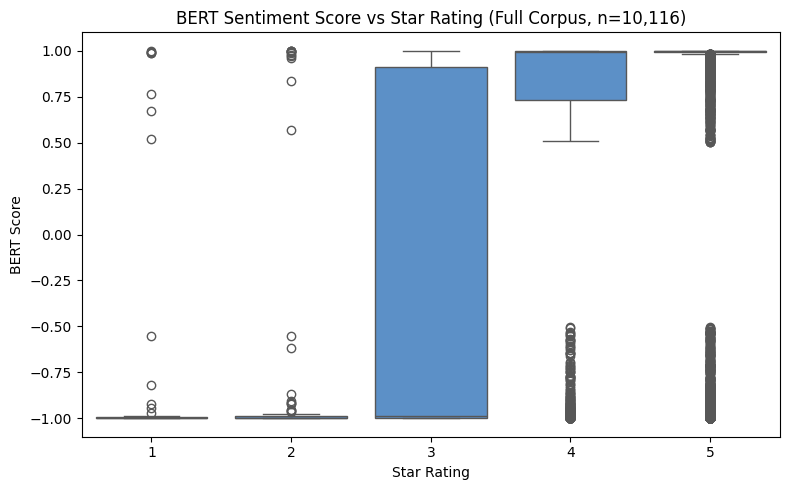

In [11]:
# Boxplot: BERT vs rating (full corpus)
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="rating", y="bert_score", data=df, color="#4a90d9", ax=ax)
ax.set_title("BERT Sentiment Score vs Star Rating (Full Corpus, n=10,116)")
ax.set_xlabel("Star Rating")
ax.set_ylabel("BERT Score")
plt.tight_layout()
plt.savefig("../Outputs/Figures/bert_full_score_by_rating.png", dpi=150)
plt.show()

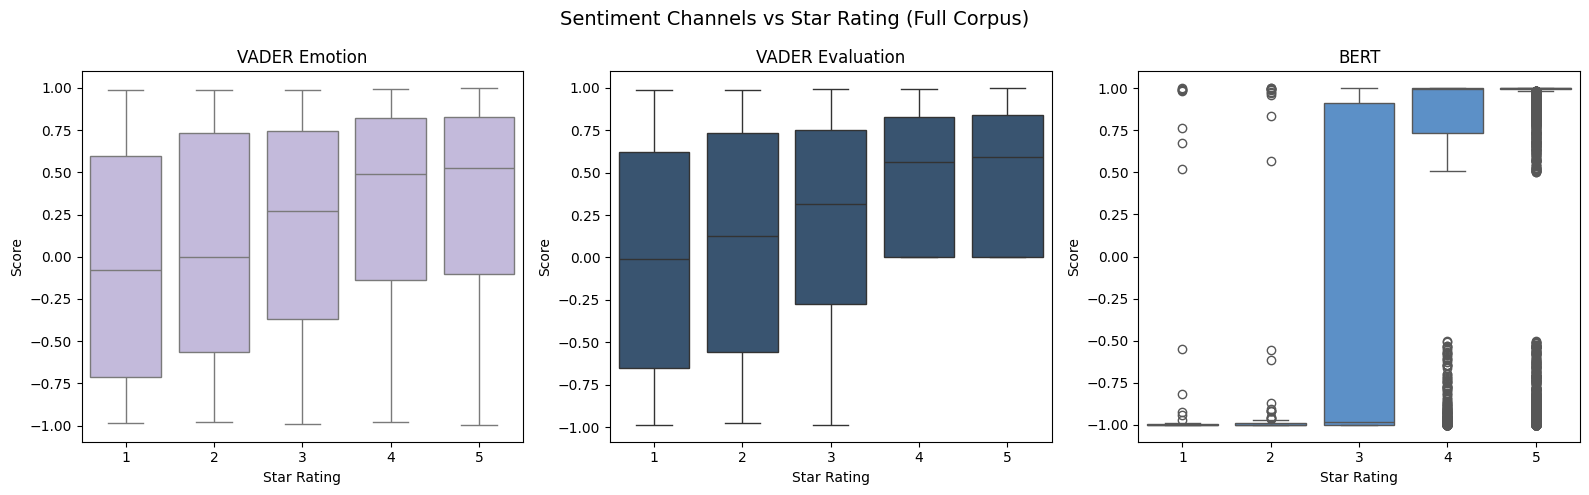

In [12]:
# All three channels vs rating — side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title, color in zip(
    axes,
    ["emo_vader", "eval_vader", "bert_score"],
    ["VADER Emotion", "VADER Evaluation", "BERT"],
    ["#c1b4e1", "#305479", "#4a90d9"]
):
    sns.boxplot(x="rating", y=col, data=df, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Star Rating")
    ax.set_ylabel("Score")

plt.suptitle("Sentiment Channels vs Star Rating (Full Corpus)", fontsize=14)
plt.tight_layout()
plt.savefig("../Outputs/Figures/all_channels_by_rating.png", dpi=150)
plt.show()

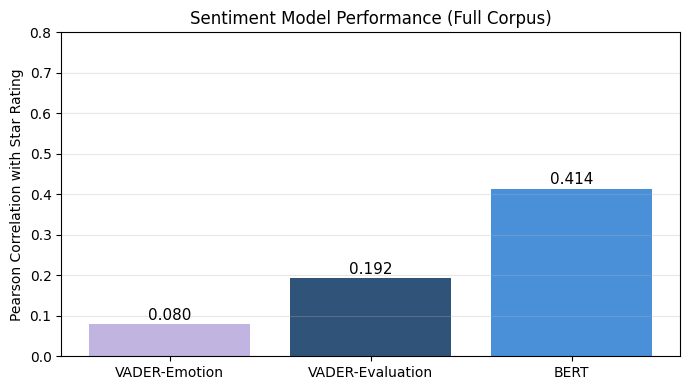

In [13]:
# Correlation bar chart — all three channels vs rating
corr_with_rating = df[["emo_vader", "eval_vader", "bert_score", "rating"]].corr()["rating"].drop("rating")

labels = ["VADER-Emotion", "VADER-Evaluation", "BERT"]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, corr_with_rating.values,
              color=["#c1b4e1", "#305479", "#4a90d9"])
ax.set_ylabel("Pearson Correlation with Star Rating")
ax.set_title("Sentiment Model Performance (Full Corpus)")
ax.set_ylim(0, 0.8)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, corr_with_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("../Outputs/Figures/sentiment_model_comparison_full.png", dpi=150)
plt.show()

## 4. Export

In [14]:
df.to_csv("../Data/Processed/ushmm_full_with_bert.csv", index=False)
print(f"Saved {len(df)} rows → ../Data/Processed/ushmm_full_with_bert.csv")
print(f"bert_score populated for all {df['bert_score'].notna().sum()} rows")

Saved 10116 rows → ../Data/Processed/ushmm_full_with_bert.csv
bert_score populated for all 10116 rows
